# Fine-Tune Pretrained Commutative Transformer Classifier

Load the commutative transformer encoder saved by notebook 12T and fine-tune the full transformer network on the current labeled action dataset.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    CommutativeTransformerClassifier,
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_estimator_on_experiment,
    load_commutative_transformer_pretraining_config,
    persist_experiment_artifacts,
    plot_training_history,
    prepare_multitask_experiment_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import build_tensor_embedding_2d, load_labeled_tensor_dataset, plot_tensor_embedding_2d

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)

In [2]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
pretraining_config_path = Path("artifacts/pretrained_commutative_transformer/config.yaml")
pretraining_config = load_commutative_transformer_pretraining_config(pretraining_config_path)
print(f"Loaded commutative transformer pretraining config from {pretraining_config_path}")
print(pretraining_config)

pretrained_encoder_path = pretraining_config.pretrained_encoder_path
model_config = pretraining_config.model_config
experiment_output_dir = Path("artifacts/nb15T_commutative_transformer_full_finetune")
persist_artifacts = True

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 6
rotation_range_degrees = 12.0
freeze_backbone = False

optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=100,
    learning_rate=5e-5,
    weight_decay=3e-3,
    early_stopping_patience=8,
    early_stopping_min_delta=0.0,
    scheduler_patience=2,
    scheduler_factor=0.7,
    scheduler_min_lr=1e-6,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    compound_weight=0.05,
    concentration_weight=0.05,
    consistency_weight=0.05,
    feature_weight=0.01,
    prototype_temperature=0.1,
)

In [3]:
if not pretrained_encoder_path.exists():
    raise FileNotFoundError(
        f"Pretrained transformer encoder not found at {pretrained_encoder_path}. "
        "Run notebook 12T first."
    )

dataset = load_labeled_tensor_dataset(dataset_artifact_path)
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)
display_experiment_summary(experiment)

,split,n_samples
0,train_augmented,1169
1,train_base,167
2,val,42
3,holdout,70


,mechanism_of_action,compound,concentration_band,n_samples
0,GABAAR_Antagonist,Gabazine,high,49
1,GABAAR_Antagonist,Bemegride,control,49
2,AChE_Inhibitor_Reversible,Galantamine,high,42
3,GABAAR_Antagonist,Gabazine,control,42
4,mAChR_Agonist_NonSelective,Bethanechol,high,42
5,mAChR_Agonist_NonSelective,Bethanechol,mid,42
6,NMDAR_Activation,Cis-ACPD,control,42
7,AChE_Inhibitor_Reversible,Donepezil,control,35
8,NMDAR_Activation,N-methyl-D-aspartate,high,35
9,AChE_Inhibitor_Reversible,Galantamine,control,35


cols:
    ep=epoch
    lr=learning_rate
    eta=estimated_time_remaining
    trL=train_loss
    trA=train_action_loss
    trCC=train_commutative_consistency_loss
    trFA=train_feature_alignment_loss
    trCo=train_compound_loss
    trCn=train_concentration_loss
    vaL=val_loss
    vaA=val_action_loss
    vaCC=val_commutative_consistency_loss
    vaFA=val_feature_alignment_loss
    vaCo=val_compound_loss
    vaCn=val_concentration_loss
     ep       lr       eta |      trL      trA     trCC     trFA     trCo     trCn |      vaL      vaA     vaCC     vaFA     vaCo     vaCn
001/100 5.00e-05     21:23 |   1.8829   1.5870   2.1729   0.1311   2.6147   1.1047 |   1.8383   1.5647   1.7120   0.1119   2.6408   1.0971
002/100 5.00e-05     35:54 |   1.8239   1.5330   2.0568   0.1945   2.6170   1.1058 |   1.8110   1.5478   1.5348   0.0953   2.6173   1.0927
003/100 5.00e-05   1:01:22 |   1.8002   1.5140   1.9693   0.1900   2.6094   1.1066 |   1.8001   1.5360   1.5779   0.0948   2.5955   1.0910
004

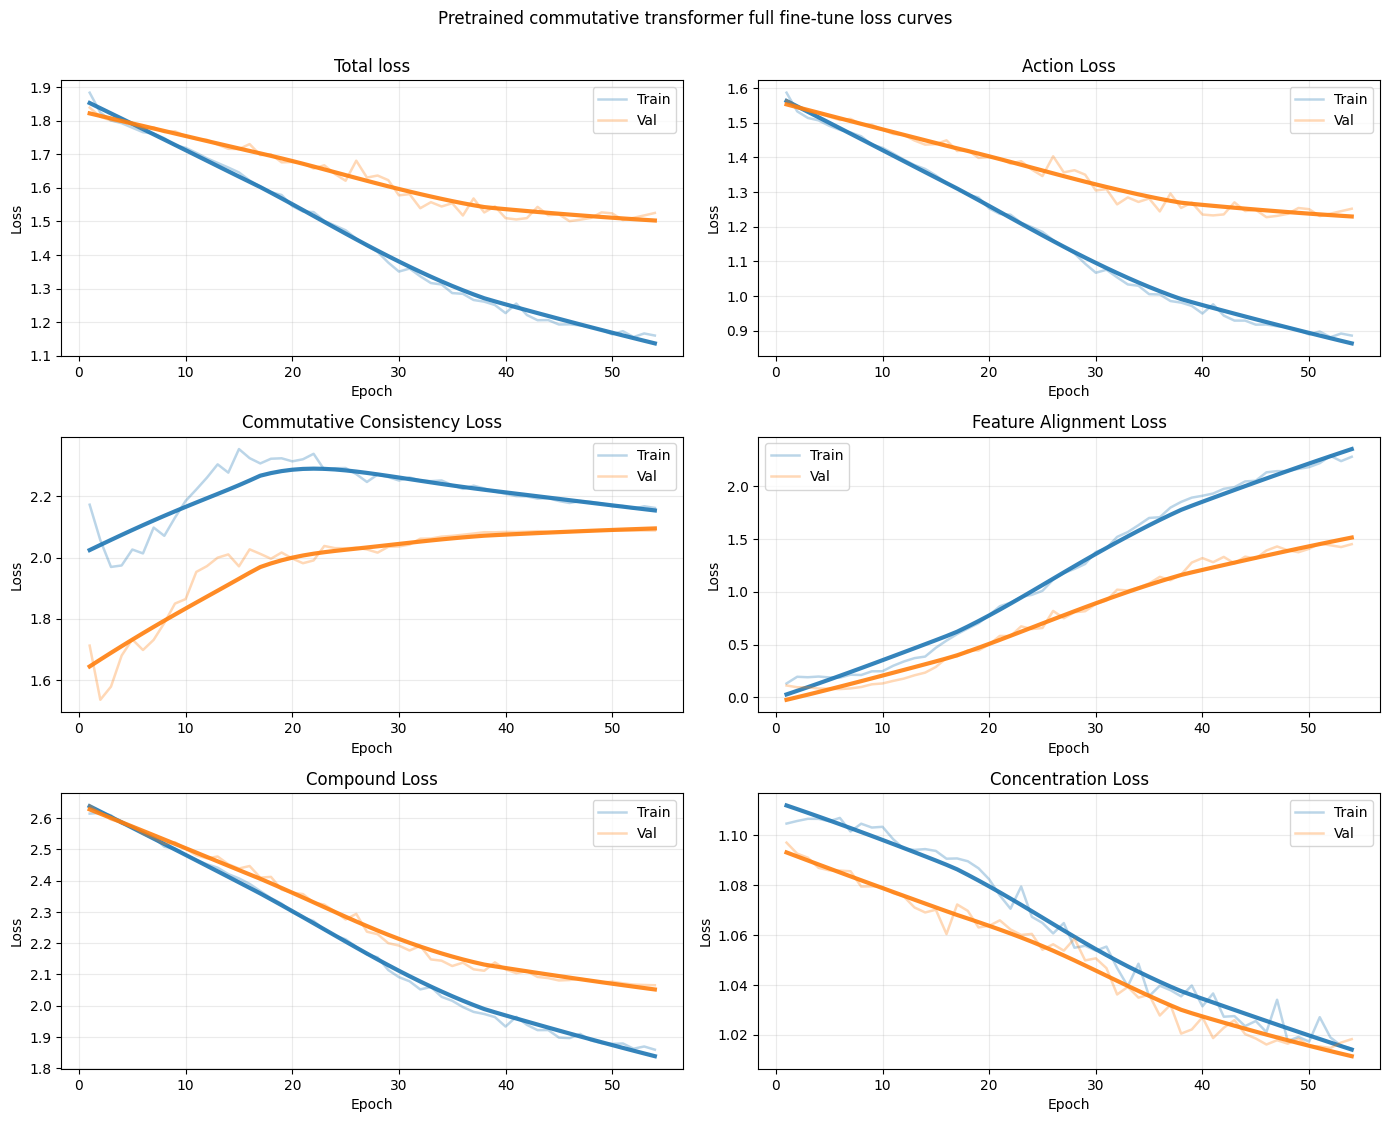

In [4]:
model = CommutativeTransformerClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
    pretrained_state_path=pretrained_encoder_path,
    freeze_backbone=freeze_backbone,
)
fit_estimator_on_experiment(model, experiment)
plot_training_history(model, title="Pretrained commutative transformer full fine-tune loss curves", loess_frac=0.6);


## Holdout report: action


,precision,recall,f1-score,support
class,,,,
Water,0.517241,0.625000,0.566038,24.0
GABAAR_Antagonist,0.533333,0.666667,0.592593,12.0
NMDAR_Activation,0.545455,0.600000,0.571429,10.0
AChE_Inhibitor_Reversible,0.500000,0.250000,0.333333,12.0
mAChR_Agonist_NonSelective,0.333333,0.250000,0.285714,12.0


,value
accuracy,0.500000
macro_precision,0.485873
macro_recall,0.478333
macro_f1,0.469821
weighted_precision,0.489548
weighted_recall,0.500000
weighted_f1,0.483412
n_samples,70.000000
roc_auc_ovr_macro,0.764013
average_precision_macro,0.494583


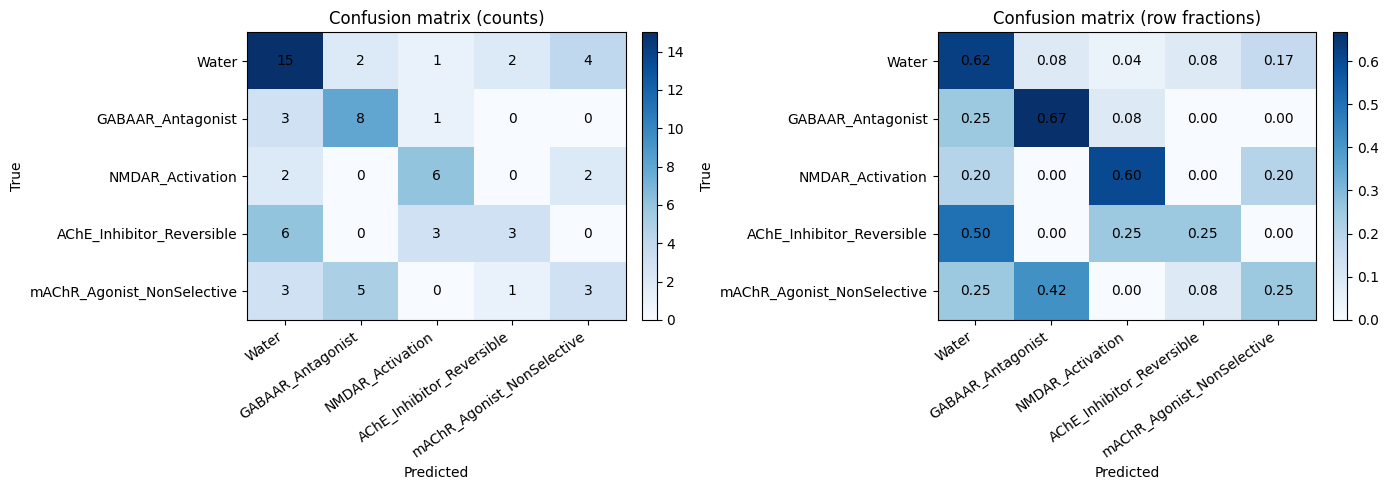


## Holdout report: compound


,precision,recall,f1-score,support
class,,,,
Control,0.37931,0.916667,0.536585,24.0
Bemegride,0.00000,0.000000,0.000000,6.0
Bicuculline,1.00000,0.333333,0.500000,3.0
Gabazine,0.00000,0.000000,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,1.00000,0.333333,0.500000,3.0
Cis-ACPD,0.00000,0.000000,0.000000,3.0
N-methyl-D-aspartate,0.50000,1.000000,0.666667,4.0
Donepezil,0.00000,0.000000,0.000000,4.0
Galantamine,0.00000,0.000000,0.000000,4.0


,value
accuracy,0.400000
macro_precision,0.221485
macro_recall,0.198718
macro_f1,0.169481
weighted_precision,0.244335
weighted_recall,0.400000
weighted_f1,0.264925
n_samples,70.000000
roc_auc_ovr_macro,0.808841
average_precision_macro,0.357163


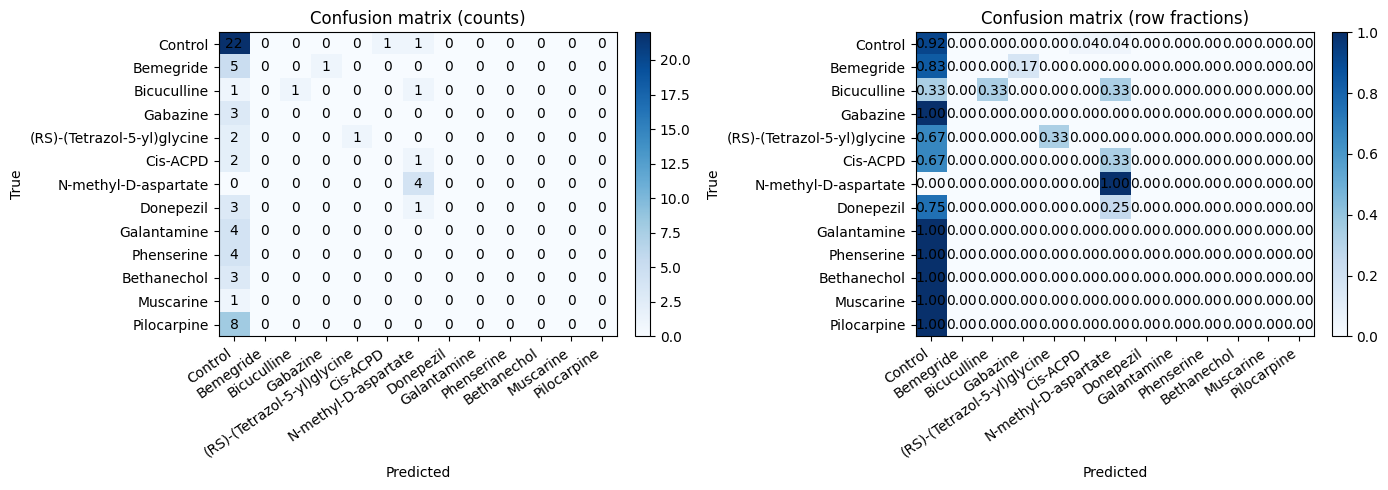


## Holdout report: concentration


,precision,recall,f1-score,support
class,,,,
control,0.451613,0.583333,0.509091,24.0
high,0.440000,0.440000,0.440000,25.0
mid,0.285714,0.190476,0.228571,21.0


,value
accuracy,0.414286
macro_precision,0.392442
macro_recall,0.404603
macro_f1,0.392554
weighted_precision,0.397696
weighted_recall,0.414286
weighted_f1,0.400260
n_samples,70.000000
roc_auc_ovr_macro,0.600954
average_precision_macro,0.436676


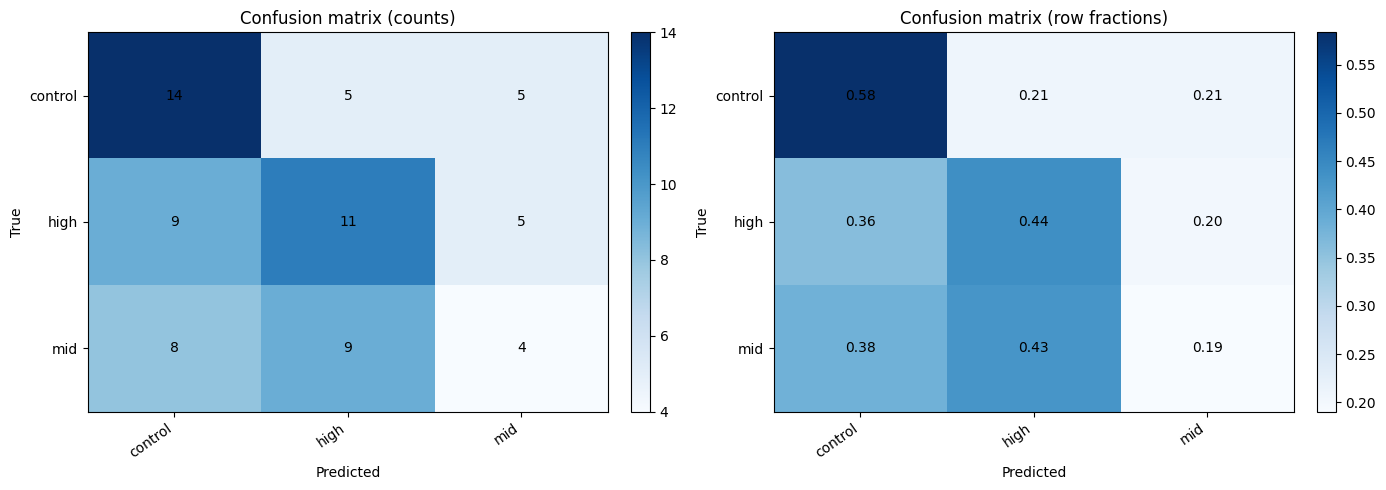

In [5]:
holdout_evaluation = display_holdout_evaluation(model, experiment)

(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

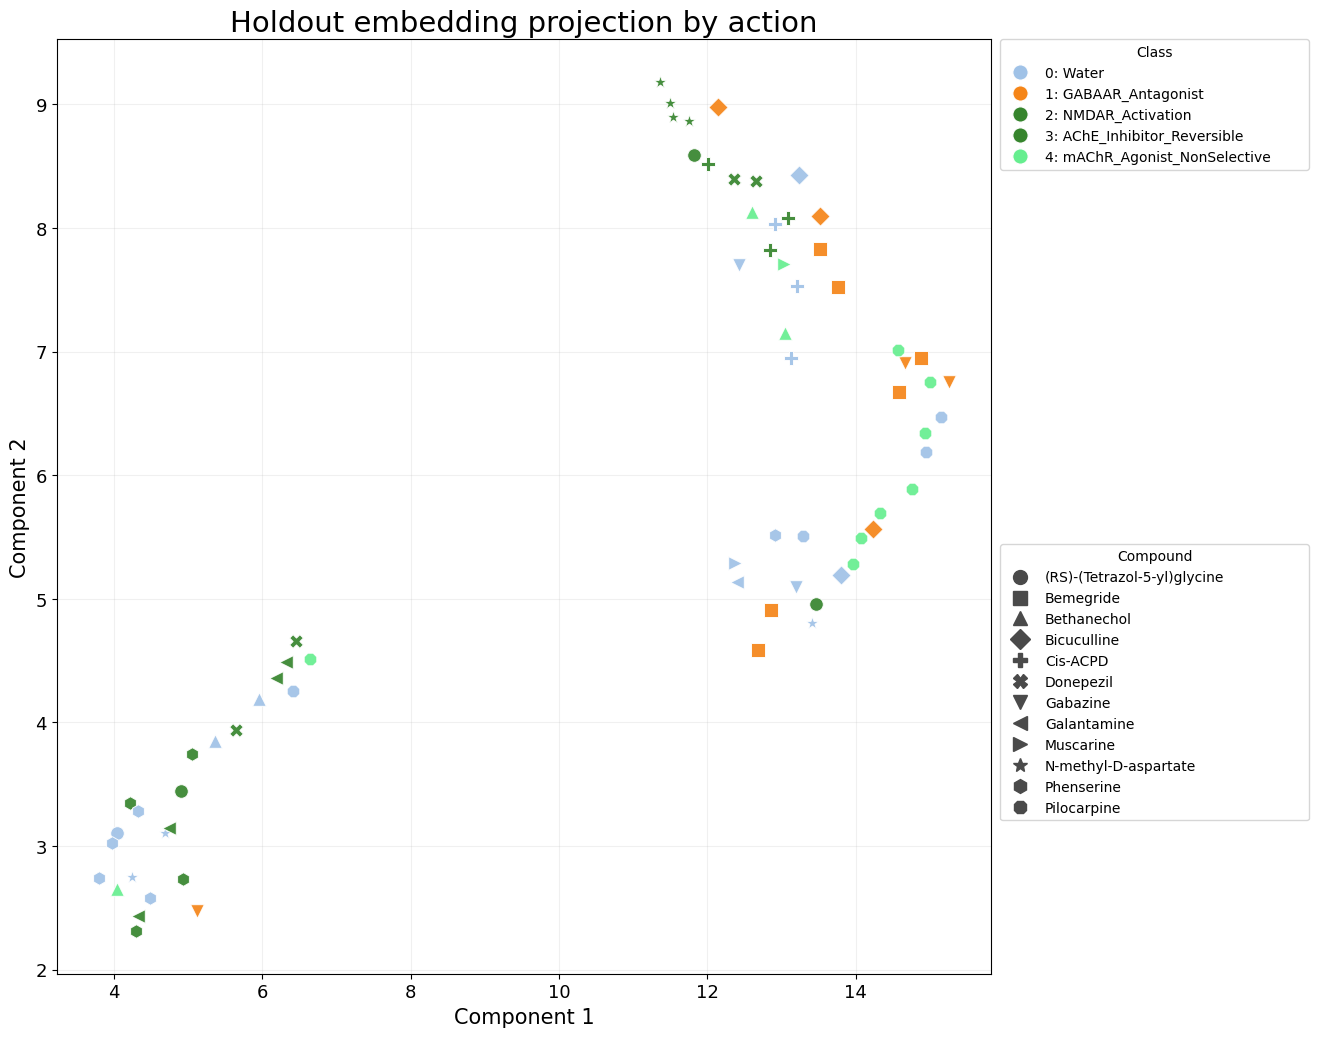

In [6]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)

In [7]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "pretraining_config_path": pretraining_config_path,
    "pretrained_encoder_path": pretrained_encoder_path,
    "freeze_backbone": freeze_backbone,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
    experiment_artifacts